<a href="https://colab.research.google.com/github/racevedowsu-edu/enzyme-kinetics-analyzer/blob/main/notebooks/enzyme_kinetics_analyzer_widget_kcat_only_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enzyme Kinetics Analyzer Widget Notebook

This version focuses on getting **WT kcat** and **Mutant kcat** working cleanly in dual mode.


<details>
<summary><b>Click for instructions</b></summary>
# Directions
1. Hit the Run all button (top left of screen)
2. Follow along below as script runs

## Section 2 -- Upload Files
- Upload your CSV file
- Make sure format is correct
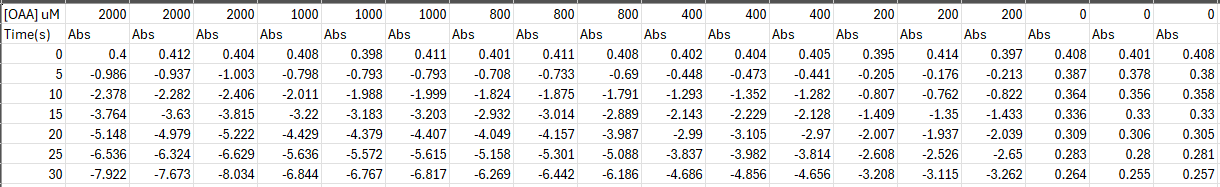
-Single Mode
    -Upload one file
-WT vs Mutant Mode (Dual mode)
    -Upload two files
## Section 5 -- Run your analysis
-Choose mode (Single vs Dual mode)
### Single Mode
1.   Select your file in Single file
2.   Choose how to calculate intial rates:
    -First N points (recommended for clean data)
    -Auto-search (recommend if unsure)
3. Optional:
    -Enable Blank correction (must have 0 uM OAA timedata)
    -Enter concentrations to Exclude from analysis (when a concentration is particularly bad)
4. (Optional but recommended) Compute kcat
    -Check Compute kcat
    -Enter the following: :
        -Stock [dimer] (uM) --> from BSA assay
        -Enzyme (uL) --> volume added to reaction
        -Total (uL) --> total reaction volume
        -Sites/dimer --> usually 2 (could be 4: please check)
5. Click Run analysis
6. Deliverables
    -Progress curves (Figure 1)
    -Michaelis-Menten fit (Figure 2)
    -Eadie-Hofstee plot (Figure 3)
    -Lineweaver-Burk plot (Figure 4)
    -Comparison Table includes:
        -Km
        -Vmax
        -kcat (if selected)
        -kcat/Km (if selected)
        
### Dual Mode
1.   Select your files: WT file & Mutant file
2.   Choose how to calculate intial rates:
    -First N points (recommended for clean data)
    -Auto-search (recommend if unsure)
3. Optional:
    -Enable Blank correction (must have 0 uM OAA timedata)
    -Enter concentrations to Exclude from analysis (when a concentration is particularly bad)
4. (Highly recommended) Compute kcat
    -Check Compute kcat
    -Enter the following for both the WT & Mutant:
        -Stock [dimer] (uM) --> from BSA assay
        -Enzyme (uL) --> volume added to reaction
        -Total (uL) --> total reaction volume
        -Sites/dimer --> usually 2 (could be 4: please check)
5. Click Run analysis
6. Deliverables
    -Progress curves (Figure 1)
    -Michaelis-Menten overlay (Figure 2)
    -Eadie-Hofstee plot overlay (Figure 3)
    -Lineweaver-Burk plot overlay(Figure 4)
    -Comparison Table includes:
        -Km (WT vs Mutant)
        -Vmax (WT vs Mutant)
        -kcat (WT vs Mutant)
        -kcat/Km (WT vs Mutant)
        -Difference (Mut - WT)
        -Percentage change

</details>



## 1. Install and import packages


In [1]:
#@title Importing Important Imports
# ⚠️ DO NOT DELETE THIS CELL
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip -q install openpyxl scipy pandas matplotlib numpy ipywidgets
    from google.colab import output
    output.enable_custom_widget_manager()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

WT_COLOR = "#648FFF"
MUT_COLOR = "#DC267F"
EH_MM_COLOR = "#785EF0"
WT_MARKER = "o"
MUT_MARKER = "s"
WT_LINE = "-"
MUT_LINE = "--"
MARKER_SIZE = 6
LINE_WIDTH = 2

def style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=15, fontweight="bold", color="black")
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold", color="black")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold", color="black")

def style_legend(ax, loc='best', bbox_to_anchor=None):
    leg = ax.legend(fontsize=10, frameon=True, loc=loc, bbox_to_anchor=bbox_to_anchor)
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontweight("bold")
    return leg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.7 MB/s eta 0:00:00


## 2. Upload files with Colab


In [2]:
#@title 📁 Upload your data files
from google.colab import files

uploaded = files.upload()
uploaded_files = list(uploaded.keys())
print("Uploaded files:", uploaded_files)


Saving mutant_data.csv to mutant_data.csv
Saving wild_type_data.csv to wild_type_data.csv
Uploaded files: ['mutant_data.csv', 'wild_type_data.csv']


## 3. Analysis Engine


In [20]:
def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

def safe_float(x):
    try:
        if pd.isna(x):
            return None
        return float(x)
    except Exception:
        return None

def load_plate_reader_file(file_path, ignored_substrates=None):
    if ignored_substrates is None:
        ignored_substrates = []

    if str(file_path).lower().endswith(".csv"):
        df = pd.read_csv(file_path, header=None)
    else:
        df = pd.read_excel(file_path, header=None)

    if df.shape[0] < 3 or df.shape[1] < 2:
        raise ValueError("File format not recognized. Expected at least 3 rows and 2 columns.")

    time = pd.to_numeric(df.iloc[2:, 0], errors="coerce").values
    substrate_headers = df.iloc[0, 1:].tolist()
    grouped, preview_rows, trace_counter = {}, [], {}

    for col_offset, raw_substrate in enumerate(substrate_headers, start=1):
        substrate = safe_float(str(raw_substrate).replace(",", ""))

        if substrate is None:
            preview_rows.append({
                "Column_Index": col_offset,
                "Header_Value": raw_substrate,
                "Parsed_Substrate_uM": np.nan,
                "Replicate_Name": "",
                "Used": "No",
                "Reason": "Non-numeric or blank header",
                "Valid_Points": 0
            })
            continue

        if substrate in ignored_substrates:
            preview_rows.append({
                "Column_Index": col_offset,
                "Header_Value": raw_substrate,
                "Parsed_Substrate_uM": substrate,
                "Replicate_Name": "",
                "Used": "No",
                "Reason": "Excluded by user",
                "Valid_Points": 0
            })
            continue

        absorbance = pd.to_numeric(df.iloc[2:, col_offset], errors="coerce").values
        mask = (~np.isnan(time)) & (~np.isnan(absorbance))
        t = time[mask]
        a = absorbance[mask]

        if len(t) < 3:
            preview_rows.append({
                "Column_Index": col_offset,
                "Header_Value": raw_substrate,
                "Parsed_Substrate_uM": substrate,
                "Replicate_Name": "",
                "Used": "No",
                "Reason": "Fewer than 3 valid points",
                "Valid_Points": int(len(t))
            })
            continue

        trace_counter[substrate] = trace_counter.get(substrate, 0) + 1
        replicate_name = f"rep{trace_counter[substrate]}"
        grouped.setdefault(substrate, []).append({
            "substrate_uM": substrate,
            "replicate_name": replicate_name,
            "column_index": col_offset,
            "time_s": t,
            "absorbance": a
        })

        preview_rows.append({
            "Column_Index": col_offset,
            "Header_Value": raw_substrate,
            "Parsed_Substrate_uM": substrate,
            "Replicate_Name": replicate_name,
            "Used": "Yes",
            "Reason": "Used",
            "Valid_Points": int(len(t))
        })

    if not grouped:
        raise ValueError("No usable traces found.")

    return grouped, pd.DataFrame(preview_rows)

def fit_initial_velocity(time_s, signal, method="first_n", first_n=5, auto_min_points=4, auto_max_fraction=0.5):
    time_s = np.asarray(time_s, dtype=float)
    signal = np.asarray(signal, dtype=float)

    if len(time_s) < 3:
        raise ValueError("Need at least 3 points to fit a line.")

    if method == "first_n":
        n = min(max(3, int(first_n)), len(time_s))
        x = time_s[:n]
        y = signal[:n]
        fit = linregress(x, y)
        return {
            "slope": fit.slope,
            "intercept": fit.intercept,
            "r2": fit.rvalue ** 2,
            "fit_idx": np.arange(n),
            "velocity_abs_per_s": abs(fit.slope)
        }

    min_pts = max(3, int(auto_min_points))
    max_pts = min(max(min_pts, int(np.floor(len(time_s) * auto_max_fraction))), len(time_s))
    best, best_score = None, None

    for n in range(min_pts, max_pts + 1):
        x = time_s[:n]
        y = signal[:n]
        fit = linregress(x, y)
        yhat = fit.intercept + fit.slope * x
        ss_res = np.sum((y - yhat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1.0 if ss_tot == 0 else 1 - ss_res / ss_tot
        score = r2 + 0.0005 * n
        if best_score is None or score > best_score:
            best_score = score
            best = {
                "slope": fit.slope,
                "intercept": fit.intercept,
                "r2": r2,
                "fit_idx": np.arange(n),
                "velocity_abs_per_s": abs(fit.slope)
            }

    return best

def convert_absorbance_rate_to_concentration_rate(rate_abs_per_s, epsilon_M_cm=6220.0, pathlength_cm=1.0):
    return (rate_abs_per_s / (epsilon_M_cm * pathlength_cm)) * 1e6

def analyze_grouped_traces(grouped_traces, method, first_n, auto_min_points, auto_max_fraction,
                           convert_to_conc=False, epsilon=6220.0, pathlength_cm=1.0):
    analyzed_traces = []

    for substrate, trace_list in grouped_traces.items():
        for trace in trace_list:
            fitres = fit_initial_velocity(
                trace["time_s"],
                trace["absorbance"],
                method=method,
                first_n=first_n,
                auto_min_points=auto_min_points,
                auto_max_fraction=auto_max_fraction
            )
            velocity = (
                convert_absorbance_rate_to_concentration_rate(
                    fitres["velocity_abs_per_s"], epsilon, pathlength_cm
                )
                if convert_to_conc else fitres["velocity_abs_per_s"]
            )
            units = "uM/s" if convert_to_conc else "Abs/s"
            analyzed_traces.append({**trace, **fitres, "velocity_raw": velocity, "velocity_units": units})

    trace_df = pd.DataFrame({
        "Substrate_uM": [x["substrate_uM"] for x in analyzed_traces],
        "Replicate": [x["replicate_name"] for x in analyzed_traces],
        "Velocity_Raw": [x["velocity_raw"] for x in analyzed_traces],
        "Velocity_units": [x["velocity_units"] for x in analyzed_traces],
        "Slope_Abs_per_s": [x["slope"] for x in analyzed_traces],
        "R2_initial_fit": [x["r2"] for x in analyzed_traces],
        "Column_Index": [x["column_index"] for x in analyzed_traces],
    }).sort_values(["Substrate_uM", "Replicate"])

    return analyzed_traces, trace_df

def apply_blank_correction(trace_df, use_blank_correction=False, blank_substrate_value=0.0):
    df = trace_df.copy()
    df["Velocity_Corrected"] = df["Velocity_Raw"]
    blank_summary, blank_mean, blank_sd, blank_n = None, np.nan, np.nan, 0

    if use_blank_correction:
        blank_df = df[df["Substrate_uM"] == blank_substrate_value].copy()
        if blank_df.empty:
            raise ValueError(f"Blank correction selected, but no {blank_substrate_value:g} uM columns were found.")
        blank_n = len(blank_df)
        blank_mean = blank_df["Velocity_Raw"].mean()
        blank_sd = blank_df["Velocity_Raw"].std(ddof=1) if blank_n > 1 else np.nan
        df.loc[df["Substrate_uM"] != blank_substrate_value, "Velocity_Corrected"] = (
            df.loc[df["Substrate_uM"] != blank_substrate_value, "Velocity_Raw"] - blank_mean
        )
        blank_summary = pd.DataFrame({
            "Blank_Substrate_uM": [blank_substrate_value],
            "Blank_N": [blank_n],
            "Blank_Mean_Velocity": [blank_mean],
            "Blank_SD_Velocity": [blank_sd]
        })

    return df, blank_summary, blank_mean, blank_sd, blank_n

def summarize_by_substrate(trace_df, use_corrected=False, exclude_zero_for_fits=True):
    velocity_col = "Velocity_Corrected" if use_corrected else "Velocity_Raw"

    grouped_summary = trace_df.groupby("Substrate_uM", as_index=False).agg(
        N=(velocity_col, "count"),
        Mean_Velocity=(velocity_col, "mean"),
        SD_Velocity=(velocity_col, lambda x: np.std(x, ddof=1) if len(x) > 1 else np.nan),
        Mean_R2=("R2_initial_fit", "mean"),
    ).sort_values("Substrate_uM")

    grouped_summary["SEM_Velocity"] = grouped_summary["SD_Velocity"] / np.sqrt(grouped_summary["N"])
    grouped_summary["Velocity_units"] = trace_df["Velocity_units"].iloc[0] if len(trace_df) else ""
    grouped_summary["Used_For_MM_LWB"] = "Yes"
    if exclude_zero_for_fits:
        grouped_summary.loc[grouped_summary["Substrate_uM"] == 0, "Used_For_MM_LWB"] = "No"

    return grouped_summary

def fit_mm_and_lwb(summary_df):
    fit_df = summary_df[summary_df["Used_For_MM_LWB"] == "Yes"].copy()
    S = fit_df["Substrate_uM"].to_numpy(dtype=float)
    v = fit_df["Mean_Velocity"].to_numpy(dtype=float)
    mask = (~np.isnan(S)) & (~np.isnan(v)) & (S > 0) & (v > 0)
    S = S[mask]
    v = v[mask]

    if len(S) < 3:
        raise ValueError("Need at least 3 positive substrate concentrations with positive mean velocities.")

    # Michaelis-Menten fit with bounds for Km
    # Vmax bounds: [0, np.inf] (velocity cannot be negative)
    # Km bounds: [10, np.inf] (no upper limit)
    p0_vmax = np.max(v) if np.max(v) > 0 else 1.0 # Ensure positive initial Vmax guess
    p0_km = np.median(S) if np.median(S) >= 10 else 100.0 # Initial Km guess with lower bound

    # Ensure p0 values are within bounds
    initial_vmax = max(0.0, p0_vmax)
    initial_km = max(10.0, p0_km) # Ensure initial Km guess is at least 10

    popt, pcov = curve_fit(michaelis_menten, S, v, p0=[initial_vmax, initial_km],
                           bounds=([0, 10], [np.inf, np.inf]), maxfev=10000)
    Vmax_mm, Km_mm = popt

    try:
        mm_sd = np.sqrt(np.diag(pcov))
        Vmax_mm_sd, Km_mm_sd = float(mm_sd[0]), float(mm_sd[1])
    except Exception:
        Vmax_mm_sd, Km_mm_sd = np.nan, np.nan

    vhat_mm = michaelis_menten(S, Vmax_mm, Km_mm)
    mm_sse = float(np.sum((v - vhat_mm) ** 2))
    ss_tot = float(np.sum((v - np.mean(v)) ** 2))
    mm_r2 = np.nan if ss_tot == 0 else float(1 - (mm_sse / ss_tot))

    # Lineweaver-Burk is a linear regression, no p0 or bounds needed
    # Eadie-Hofstee is a linear regression, no p0 or bounds needed

    eh = linregress(v / S, v)
    Vmax_eh, Km_eh = eh.intercept, -eh.slope
    Vmax_eh_sd, Km_eh_sd, eh_r2 = getattr(eh, "intercept_stderr", np.nan), getattr(eh, "stderr", np.nan), eh.rvalue ** 2

    lb = linregress(1.0 / S, 1.0 / v)
    if lb.intercept == 0:
        raise ValueError("Lineweaver-Burk intercept was zero; cannot compute Vmax.")
    Vmax_lb = 1.0 / lb.intercept
    Km_lb = lb.slope * Vmax_lb
    intercept_sd = getattr(lb, "intercept_stderr", np.nan)
    slope_sd = getattr(lb, "stderr", np.nan)
    Vmax_lb_sd = np.nan if np.isnan(intercept_sd) else abs((-1.0 / (lb.intercept ** 2)) * intercept_sd)
    Km_lb_sd = np.nan if (np.isnan(slope_sd) or np.isnan(Vmax_lb_sd)) else float(
        np.sqrt((Vmax_lb * slope_sd) ** 2 + (lb.slope * Vmax_lb_sd) ** 2)
    )

    return {
        "S": S,
        "v": v,
        "Vmax_mm": Vmax_mm,
        "Km_mm": Km_mm,
        "Vmax_mm_sd": Vmax_mm_sd,
        "Km_mm_sd": Km_mm_sd,
        "MM_SSE": mm_sse, # Added MM_SSE
        "MM_R2": mm_r2,
        "Vmax_eh": Vmax_eh,
        "Km_eh": Km_eh,
        "Vmax_eh_sd": Vmax_eh_sd,
        "Km_eh_sd": Km_eh_sd,
        "eh_slope": eh.slope,
        "eh_intercept": eh.intercept,
        "eh_r2": eh_r2,
        "Vmax_lb": Vmax_lb,
        "Km_lb": Km_lb,
        "Vmax_lb_sd": Vmax_lb_sd,
        "Km_lb_sd": Km_lb_sd,
        "lb_slope": lb.slope,
        "lb_intercept": lb.intercept,
        "lb_r2": lb.rvalue ** 2,
    }

def calculate_final_dimer_concentration(stock_dimer_uM, enzyme_volume_uL, total_volume_uL):
    return stock_dimer_uM * (enzyme_volume_uL / total_volume_uL)

def convert_dimer_to_active_site_concentration(final_dimer_uM, active_sites_per_dimer=2):
    return final_dimer_uM * active_sites_per_dimer

def compute_kcat(vmax_value, active_site_uM):
    return vmax_value / active_site_uM

def run_dataset_analysis(file_path, settings, label="Dataset"):
    grouped_traces, preview_df = load_plate_reader_file(file_path, ignored_substrates=settings["ignored"])
    analyzed_traces, trace_df = analyze_grouped_traces(
        grouped_traces,
        method=settings["method"],
        first_n=settings["first_n"],
        auto_min_points=settings["auto_min"],
        auto_max_fraction=settings["auto_frac"],
        convert_to_conc=settings["convert"],
        epsilon=settings["epsilon"],
        pathlength_cm=settings["pathlength"]
    )
    trace_df, blank_summary_df, blank_mean, blank_sd, blank_n = apply_blank_correction(
        trace_df,
        use_blank_correction=settings["do_blank"],
        blank_substrate_value=settings["blank_sub"]
    )
    summary_df = summarize_by_substrate(trace_df, use_corrected=settings["do_blank"], exclude_zero_for_fits=True)
    fitres = fit_mm_and_lwb(summary_df)

    final_dimer_uM = final_active_site_uM = kcat_mm = kcat_over_km = None
    if settings["compute_kcat"]:
        final_dimer_uM = calculate_final_dimer_concentration(
            settings.get("stock_dimer", np.nan),
            settings["enzyme_vol"],
            settings["total_vol"]
        )
        final_active_site_uM = convert_dimer_to_active_site_concentration(
            final_dimer_uM, settings["sites_per_dimer"]
        )
        kcat_mm = compute_kcat(fitres["Vmax_mm"], final_active_site_uM)
        kcat_over_km = kcat_mm / fitres["Km_mm"]

    return {
        "label": label,
        "preview_df": preview_df,
        "analyzed_traces": analyzed_traces,
        "trace_df": trace_df,
        "summary_df": summary_df,
        "fitres": fitres,
        "blank_summary_df": blank_summary_df,
        "blank_mean": blank_mean,
        "blank_sd": blank_sd,
        "blank_n": blank_n,
        "final_dimer_uM": final_dimer_uM,
        "final_active_site_uM": final_active_site_uM,
        "kcat_mm": kcat_mm,
        "kcat_over_km": kcat_over_km,
    }

## 4. Plotting and export helpers


In [25]:
def make_single_panel(result, title_prefix='', save_base=None):
    units = result['summary_df']['Velocity_units'].iloc[0] if len(result['summary_df']) else 'Velocity'
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # Define a list of markers to cycle through for different concentrations
    concentration_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*', 'X', '+']
    # Colorblind-friendly palette, avoiding the blue from WT_COLOR for Figure 1 distinction
    colorblind_colors = ['#E69F00', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#000000'] # Orange, Bluish Green, Vermillion, Reddish Purple, Yellow, Black

    substrates = sorted({x['substrate_uM'] for x in result['analyzed_traces']})

    # Create a mapping from substrate to marker index and color index
    substrate_to_marker_idx = {sub: i % len(concentration_markers) for i, sub in enumerate(substrates)}
    substrate_to_color_idx = {sub: i % len(colorblind_colors) for i, sub in enumerate(substrates)}

    for substrate in substrates:
        traces = [x for x in result['analyzed_traces'] if x['substrate_uM'] == substrate]
        mean_v = np.nanmean([tr.get('velocity_raw', np.nan) for tr in traces])
        tr = traces[0]

        t = tr['time_s']
        a = tr['absorbance']
        fit_idx = tr['fit_idx']

        current_marker = concentration_markers[substrate_to_marker_idx[substrate]]
        current_color = colorblind_colors[substrate_to_color_idx[substrate]]

        fit_mask = np.zeros(len(t), dtype=bool)
        fit_mask[fit_idx] = True

        # all points: faded
        ax1.plot(
            t, a,
            marker=current_marker,
            linestyle='None',
            color=current_color,
            markersize=MARKER_SIZE,
            linewidth=1.5,
            alpha=0.25,
            label=None
        )

        # fit-used points: bright
        ax1.plot(
            t[fit_mask], a[fit_mask],
            marker=current_marker,
            linestyle='None',
            color=current_color,
            markersize=MARKER_SIZE,
            alpha=1.0,
            label=f"{substrate:.0f} uM ({mean_v:.2f})"
        )

        # fitted line only over chosen region
        xfit = t[fit_idx]
        yfit = tr['intercept'] + tr['slope'] * xfit
        ax1.plot(
            xfit, yfit,
            linestyle='--',
            color=current_color,
            linewidth=2,
            alpha=1.0
        )

    style_axes(ax1, 'Figure 1. Progress Curves', 'Time (s)', 'Absorbance')
    style_legend(ax1)

    # Michaelis-Menten plot (Figure 2)
    all_summary = result['summary_df']

    # Plot all points (open markers for excluded, faded color)
    if not all_summary.empty:
        # Excluded points (alpha faded, open marker)
        excluded_summary = all_summary[all_summary['Used_For_MM_LWB'] == 'No']
        if not excluded_summary.empty:
            ax2.errorbar(
                excluded_summary['Substrate_uM'], excluded_summary['Mean_Velocity'], yerr=excluded_summary['SD_Velocity'],
                fmt=WT_MARKER, color=WT_COLOR, markersize=MARKER_SIZE, capsize=4, alpha=0.5, fillstyle='none',
                label='_nolegend_'
            )

        # Included points (full marker, brighter color)
        used_for_fit_summary = all_summary[all_summary['Used_For_MM_LWB'] == 'Yes']
        if not used_for_fit_summary.empty:
            ax2.errorbar(
                used_for_fit_summary['Substrate_uM'], used_for_fit_summary['Mean_Velocity'], yerr=used_for_fit_summary['SD_Velocity'],
                fmt=WT_MARKER, color=WT_COLOR, markersize=MARKER_SIZE, capsize=4, alpha=1.0, fillstyle='full',
                label='_nolegend_'
            )

    # Plot the MM fit curve
    S_for_curve = result['fitres']['S'] # The S values used to generate the curve
    if len(S_for_curve) > 0:
        Sfit = np.linspace(0, max(S_for_curve) * 1.1, 300)
        ax2.plot(
            Sfit, michaelis_menten(Sfit, result['fitres']['Vmax_mm'], result['fitres']['Km_mm']),
            color=WT_COLOR, linestyle=WT_LINE, linewidth=LINE_WIDTH,
            label=f"MM: Km={result['fitres']['Km_mm']:.2f}±{result['fitres']['Km_mm_sd']:.2f} uM\n"
                  f"Vmax={result['fitres']['Vmax_mm']:.2f}±{result['fitres']['Vmax_mm_sd']:.2f} {units}"
        )
    style_axes(ax2, 'Figure 2. Michaelis-Menten', 'Substrate (uM)', f'Initial velocity ({units})')
    style_legend(ax2, loc='lower right')

    x_eh, y_eh = result['fitres']['v'] / result['fitres']['S'], result['fitres']['v']
    xline_eh = np.linspace(0, max(x_eh) * 1.1, 300)
    ax3.scatter(x_eh, y_eh, color=WT_COLOR, marker=WT_MARKER, s=MARKER_SIZE**2, label='_nolegend_')
    ax3.plot(
        xline_eh, result['fitres']['Vmax_mm'] - result['fitres']['Km_mm'] * xline_eh,
        color=WT_COLOR, linestyle=WT_LINE, linewidth=LINE_WIDTH, # MM fit line to WT_COLOR solid
        label=f"From MM: Km={result['fitres']['Km_mm']:.2f}±{result['fitres']['Km_mm_sd']:.2f} uM\n"
              f"Vmax={result['fitres']['Vmax_mm']:.2f}±{result['fitres']['Vmax_mm_sd']:.2f} {units}"
    )
    ax3.plot(
        xline_eh, result['fitres']['eh_intercept'] + result['fitres']['eh_slope'] * xline_eh,
        color='black', linestyle='--', linewidth=LINE_WIDTH, # EH fit line to black dashed
        label=f"EH fit: Km={result['fitres']['Km_eh']:.2f}±{result['fitres']['Km_eh_sd']:.2f} uM\n"
              f"Vmax={result['fitres']['Vmax_eh']:.2f}±{result['fitres']['Vmax_eh_sd']:.2f} {units}"
    )
    style_axes(ax3, 'Figure 3. Eadie-Hofstee', f'v/[S] ({units}/uM)', f'v ({units})')
    style_legend(ax3)

    invS, invv = 1.0 / result['fitres']['S'], 1.0 / result['fitres']['v']
    xline = np.linspace(0, max(invS) * 1.1, 300)
    yline = result['fitres']['lb_intercept'] + result['fitres']['lb_slope'] * xline
    ax4.scatter(invS, invv, color=WT_COLOR, marker=WT_MARKER, s=MARKER_SIZE**2, label='_nolegend_')
    ax4.plot(
        xline, yline,
        color=WT_COLOR, linestyle=WT_LINE, linewidth=LINE_WIDTH,
        label=f"LWB: Km={result['fitres']['Km_lb']:.2f}±{result['fitres']['Km_lb_sd']:.2f} uM\n"
              f"Vmax={result['fitres']['Vmax_lb']:.2f}±{result['fitres']['Vmax_lb_sd']:.2f} {units}"
    )
    style_axes(ax4, 'Figure 4. Lineweaver-Burk', '1/[S] (1/uM)', f'1/v (1/({units}))')
    style_legend(ax4)

    fig.suptitle(f'{title_prefix} Kinetic Analysis', fontsize=15, fontweight='bold', color='black')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_base:
        fig.savefig(save_base + '_kinetics_panel.png', dpi=300, bbox_inches='tight')
        fig.savefig(save_base + '_kinetics_panel.pdf', bbox_inches='tight')
    plt.show()

def make_multi_panel(all_results, title_prefix='', save_base=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # Define distinct markers and linestyles for different datasets
    # Use WT_COLOR, MUT_COLOR, etc. defined globally
    concentration_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*', 'X', '+']

    # Colormap for progress curves if there are many mutants
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    num_colors = len(colors)

    for i, (label, result) in enumerate(all_results.items()):
        is_wt = label == 'WT'
        color = WT_COLOR if is_wt else MUT_COLOR
        # The 'marker' variable defined here is used for MM, EH, LWB plots for the dataset
        dataset_marker = WT_MARKER if is_wt else MUT_MARKER
        linestyle = WT_LINE if is_wt else MUT_LINE
        # For progress curves, use a cycle of colors if there are many concentrations or datasets
        progress_curve_color_base = colors[i % num_colors] # Use cycle for distinct progress curves

        units = result['summary_df']['Velocity_units'].iloc[0] if len(result['summary_df']) else 'Velocity'

        # Figure 1: Progress Curves (often too crowded to overlay all perfectly)
        # For multi-panel, we can plot one representative curve per concentration for each dataset
        substrates_in_result = sorted({x['substrate_uM'] for x in result['analyzed_traces']})
        # Create a mapping from substrate to marker index for the progress curves
        substrate_to_marker_idx = {sub: j % len(concentration_markers) for j, sub in enumerate(substrates_in_result)}

        for sub_idx, substrate in enumerate(substrates_in_result):
            traces_at_sub = [x for x in result['analyzed_traces'] if x['substrate_uM'] == substrate]
            if traces_at_sub: # Take the first trace as representative
                tr = traces_at_sub[0]
                t = tr['time_s']
                a = tr['absorbance']
                fit_idx = tr['fit_idx']

                fit_mask = np.zeros(len(t), dtype=bool)
                fit_mask[fit_idx] = True

                # Use a specific marker for each concentration
                current_concentration_marker = concentration_markers[substrate_to_marker_idx[substrate]]

                # Plot only the fitted portion for clarity
                ax1.plot(
                    t[fit_mask], a[fit_mask],
                    marker=current_concentration_marker, # Use concentration-specific marker
                    linestyle='None',
                    color=progress_curve_color_base, # Use a unique color for each dataset's concentrations
                    markersize=MARKER_SIZE,
                    alpha=1.0,
                    label=f"{label} {substrate:.0f} uM"
                )
                xfit = t[fit_idx]
                yfit = tr['intercept'] + tr['slope'] * xfit
                ax1.plot(
                    xfit, yfit,
                    linestyle=linestyle,
                    color=progress_curve_color_base,
                    linewidth=LINE_WIDTH,
                    alpha=1.0
                )

        # Figure 2: Michaelis-Menten
        all_summary = result['summary_df']
        if not all_summary.empty:
            used_for_fit_summary = all_summary[all_summary['Used_For_MM_LWB'] == 'Yes']
            if not used_for_fit_summary.empty:
                ax2.errorbar(
                    used_for_fit_summary['Substrate_uM'], used_for_fit_summary['Mean_Velocity'], yerr=used_for_fit_summary['SD_Velocity'],
                    fmt=dataset_marker, color=color, markersize=MARKER_SIZE, capsize=4, alpha=1.0, fillstyle='full',
                    label=f'{label} Data'
                )

        S_for_curve = result['fitres']['S']
        if len(S_for_curve) > 0:
            Sfit = np.linspace(0, max(S_for_curve) * 1.1, 300)
            ax2.plot(
                Sfit, michaelis_menten(Sfit, result['fitres']['Vmax_mm'], result['fitres']['Km_mm']),
                color=color, linestyle=linestyle, linewidth=LINE_WIDTH,
                label=f"{label} MM Fit: Km={result['fitres']['Km_mm']:.2g}, Vmax={result['fitres']['Vmax_mm']:.2g}"
            )

        # Figure 3: Eadie-Hofstee
        if len(result['fitres']['S']) > 0 and len(result['fitres']['v']) > 0:
            x_eh, y_eh = result['fitres']['v'] / result['fitres']['S'], result['fitres']['v']
            xline_eh = np.linspace(0, max(x_eh) * 1.1, 300)
            ax3.scatter(x_eh, y_eh, color=color, marker=dataset_marker, s=MARKER_SIZE**2, label=f'{label} Data')
            ax3.plot(
                xline_eh, result['fitres']['Vmax_mm'] - result['fitres']['Km_mm'] * xline_eh,
                color=color, linestyle=linestyle, linewidth=LINE_WIDTH,
                label=f"{label} MM-derived line"
            )

        # Figure 4: Lineweaver-Burk
        if len(result['fitres']['S']) > 0 and len(result['fitres']['v']) > 0:
            invS, invv = 1.0 / result['fitres']['S'], 1.0 / result['fitres']['v']
            xline_lb = np.linspace(0, max(invS) * 1.1, 300)
            yline_lb = result['fitres']['lb_intercept'] + result['fitres']['lb_slope'] * xline_lb
            ax4.scatter(invS, invv, color=color, marker=dataset_marker, s=MARKER_SIZE**2, label=f'{label} Data')
            ax4.plot(
                xline_lb, yline_lb,
                color=color, linestyle=linestyle, linewidth=LINE_WIDTH,
                label=f"{label} LWB Fit: Km={result['fitres']['Km_lb']:.2g}, Vmax={result['fitres']['Vmax_lb']:.2g}"
            )

    # Style all axes after plotting all datasets
    style_axes(ax1, 'Figure 1. Progress Curves', 'Time (s)', 'Absorbance')
    style_legend(ax1, loc='upper left', bbox_to_anchor=(1, 1))

    style_axes(ax2, 'Figure 2. Michaelis-Menten', 'Substrate (uM)', f'Initial velocity ({units})')
    style_legend(ax2, loc='lower right')

    style_axes(ax3, 'Figure 3. Eadie-Hofstee', f'v/[S] ({units}/uM)', f'v ({units})')
    style_legend(ax3)

    style_axes(ax4, 'Figure 4. Lineweaver-Burk', '1/[S] (1/uM)', f'1/v (1/({units}))')
    style_legend(ax4)

    fig.suptitle(f'{title_prefix} Kinetic Analysis', fontsize=16, fontweight='bold', color='black')
    fig.tight_layout(rect=[0, 0, 0.95, 0.97]) # Adjust rect to make space for ax1 legend

    if save_base:
        fig.savefig(save_base + '_comparison_panel.png', dpi=300, bbox_inches='tight')
        fig.savefig(save_base + '_comparison_panel.pdf', bbox_inches='tight')
    plt.show()

## 5. Widget interface


In [26]:
#@title 🚀 Run your analysis

if 'uploaded_files' not in globals():
    uploaded_files = []

mode_widget = widgets.ToggleButtons(
    options=[('Single dataset', 'single'), ('Multi-dataset', 'multi')],
    value='single',
    description='Mode:'
)

single_file_widget = widgets.Dropdown(options=uploaded_files, description='Single file:')
wt_file_widget = widgets.Dropdown(options=uploaded_files, description='WT file:')

fit_method_widget = widgets.Dropdown(
    options=[('First N points', 'first_n'), ('Auto-search', 'auto')],
    value='first_n',
    description='Fit method:'
)
first_n_widget = widgets.BoundedIntText(value=5, min=3, max=50, description='First N:')
auto_min_widget = widgets.BoundedIntText(value=4, min=3, max=50, description='Auto min:')
auto_frac_widget = widgets.FloatText(value=0.5, description='Auto frac:')

convert_widget = widgets.Checkbox(value=True, description='Beer-Lambert conversion')
epsilon_widget = widgets.FloatText(value=6220.0, description='Epsilon:')
pathlength_widget = widgets.FloatText(value=1.0, description='Path length:')

blank_widget = widgets.Checkbox(value=True, description='Blank correction')
blank_sub_widget = widgets.FloatText(value=0.0, description='Blank uM:')

# Individual exclusion widgets
single_exclude_widget = widgets.Text(value='', description='Exclude uM:')
wt_exclude_widget = widgets.Text(value='', description='WT Exclude uM:')

kcat_widget = widgets.Checkbox(value=False, description='Compute kcat')

# Single-mode kcat inputs
stock_dimer_mg_per_mL_widget = widgets.FloatText(value=1.0, description='Stock dimer (mg/mL):')
mw_dimer_kda_widget = widgets.FloatText(value=60.0, description='MW dimer (kDa):')
enzyme_vol_widget = widgets.FloatText(value=10.0, description='Enzyme (uL):')
total_vol_widget = widgets.FloatText(value=1000.0, description='Total (uL):')
sites_widget = widgets.FloatText(value=2.0, description='Sites/dimer:')

# WT kcat inputs for multi-dataset mode
wt_stock_dimer_mg_per_mL_widget = widgets.FloatText(value=1.0, description='WT Stock (mg/mL):')
wt_mw_dimer_kda_widget = widgets.FloatText(value=60.0, description='WT MW (kDa):')
wt_enzyme_vol_widget = widgets.FloatText(value=10.0, description='WT Enzyme (uL):')
wt_total_vol_widget = widgets.FloatText(value=1000.0, description='WT Total (uL):')
wt_sites_widget = widgets.FloatText(value=2.0, description='WT Sites/dimer:')

# Dynamic Mutant Inputs
mutant_inputs = [] # List to hold dictionaries of mutant widgets
mutant_widgets_container = widgets.VBox([]) # Container for all mutant input groups

def create_mutant_input_group(mutant_id):
    file_dropdown = widgets.Dropdown(options=uploaded_files, description=f'Mutant {mutant_id} file:')
    stock_dimer_mg_per_mL = widgets.FloatText(value=1.0, description=f'Mut {mutant_id} Stock (mg/mL):')
    mw_dimer_kda = widgets.FloatText(value=60.0, description=f'Mut {mutant_id} MW (kDa):')
    enzyme_vol = widgets.FloatText(value=10.0, description=f'Mut {mutant_id} Enzyme (uL):')
    total_vol = widgets.FloatText(value=1000.0, description=f'Mut {mutant_id} Total (uL):')
    sites = widgets.FloatText(value=2.0, description=f'Mut {mutant_id} Sites/dimer:')
    exclude = widgets.Text(value='', description=f'Mut {mutant_id} Exclude uM:')

    remove_button = widgets.Button(description=f'Remove Mutant {mutant_id}', button_style='danger')

    input_group_box = widgets.VBox([
        widgets.HBox([file_dropdown, exclude]),
        widgets.HBox([stock_dimer_mg_per_mL, mw_dimer_kda, enzyme_vol, total_vol, sites]),
        widgets.HBox([remove_button])
    ], layout=widgets.Layout(border='1px solid lightgray', margin='5px 0', padding='5px'))

    return {
        'id': mutant_id,
        'file_widget': file_dropdown,
        'stock_dimer_mg_per_mL_widget': stock_dimer_mg_per_mL,
        'mw_dimer_kda_widget': mw_dimer_kda,
        'enzyme_vol_widget': enzyme_vol,
        'total_vol_widget': total_vol,
        'sites_widget': sites,
        'exclude_widget': exclude,
        'remove_button': remove_button,
        'box': input_group_box
    }

def add_mutant_input_group(b=None):
    global mutant_inputs
    mutant_id = len(mutant_inputs) + 1
    new_mutant = create_mutant_input_group(mutant_id)
    mutant_inputs.append(new_mutant)
    mutant_widgets_container.children = [m['box'] for m in mutant_inputs]
    new_mutant['remove_button'].on_click(lambda btn: remove_mutant_input_group(new_mutant['id']))

def remove_mutant_input_group(mutant_id):
    global mutant_inputs
    mutant_inputs = [m for m in mutant_inputs if m['id'] != mutant_id]
    for i, m in enumerate(mutant_inputs):
        m['id'] = i + 1
        m['file_widget'].description = f'Mutant {m["id"]} file:'
        m['stock_dimer_mg_per_mL_widget'].description = f'Mut {m["id"]} Stock (mg/mL):'
        m['mw_dimer_kda_widget'].description = f'Mut {m["id"]} MW (kDa):'
        m['enzyme_vol_widget'].description = f'Mut {m["id"]} Enzyme (uL):'
        m['total_vol_widget'].description = f'Mut {m["id"]} Total (uL):'
        m['sites_widget'].description = f'Mut {m["id"]} Sites/dimer:'
        m['exclude_widget'].description = f'Mut {m["id"]} Exclude uM:'
        m['remove_button'].description = f'Remove Mutant {m["id"]}'
    mutant_widgets_container.children = [m['box'] for m in mutant_inputs]

add_mutant_button = widgets.Button(description='Add Mutant', button_style='info')
add_mutant_button.on_click(add_mutant_input_group)

run_button = widgets.Button(description='Run analysis', button_style='success')
out = widgets.Output()

def parse_excluded(text):
    text = text.strip()
    if not text:
        return []
    return [float(x.strip()) for x in text.split(',') if x.strip()]

single_box = widgets.VBox([
    widgets.HTML("<b>Single-mode file</b>"),
    widgets.HBox([single_file_widget, single_exclude_widget])
])
multi_box = widgets.VBox([
    widgets.HTML("<b>WT file</b>"),
    widgets.HBox([wt_file_widget, wt_exclude_widget]),
    widgets.HTML("<b>WT kcat inputs:</b>"),
    widgets.HBox([wt_stock_dimer_mg_per_mL_widget, wt_mw_dimer_kda_widget, wt_enzyme_vol_widget, wt_total_vol_widget, wt_sites_widget]),
    widgets.HTML("<b>Mutant Files and kcat Inputs</b>"),
    add_mutant_button,
    mutant_widgets_container
])

files_box = widgets.VBox([single_box, multi_box])
multi_box.layout.display = 'none'

def update_mode(change):
    if change['new'] == 'single':
        single_box.layout.display = 'block'
        multi_box.layout.display = 'none'
    else: # multi-dataset mode
        single_box.layout.display = 'none'
        multi_box.layout.display = 'block'
        # Ensure at least one mutant input is present if none exist
        if not mutant_inputs:
            add_mutant_input_group()

mode_widget.observe(update_mode, names='value')
update_mode({'new': mode_widget.value})

def convert_mg_per_ml_to_uM(stock_mg_per_mL, mw_kda):
    if mw_kda == 0:
        raise ValueError("Molecular weight (kDa) cannot be zero for concentration conversion.")
    return (stock_mg_per_mL * 1000) / mw_kda

def run_dataset_analysis(file_path, settings, label="Dataset"):
    grouped_traces, preview_df = load_plate_reader_file(file_path, ignored_substrates=settings["ignored"])
    analyzed_traces, trace_df = analyze_grouped_traces(
        grouped_traces,
        method=settings["method"],
        first_n=settings["first_n"],
        auto_min_points=settings["auto_min"],
        auto_max_fraction=settings["auto_frac"],
        convert_to_conc=settings["convert"],
        epsilon=settings["epsilon"],
        pathlength_cm=settings["pathlength"]
    )
    trace_df, blank_summary_df, blank_mean, blank_sd, blank_n = apply_blank_correction(
        trace_df,
        use_blank_correction=settings["do_blank"],
        blank_substrate_value=settings["blank_sub"]
    )

    # --- Calculations based on original (uM/s or Abs/s) velocities ----
    # These are used for kcat calculation (which requires uM/s for Vmax to get s^-1 for kcat)
    summary_df_original_vel = summarize_by_substrate(trace_df, use_corrected=settings["do_blank"], exclude_zero_for_fits=True)
    fitres_original_vel = fit_mm_and_lwb(summary_df_original_vel)

    final_dimer_uM = np.nan
    final_active_site_uM = np.nan
    kcat_mm = np.nan
    kcat_over_km = np.nan
    mg_protein_in_assay = np.nan

    if settings["compute_kcat"]:
        # Calculate protein concentration for kcat
        if settings["enzyme_vol"] <= 0 or settings["stock_dimer_mg_per_mL"] <= 0:
            raise ValueError("Enzyme volume and stock dimer concentration must be positive for kcat calculation.")

        # Total mg of protein in the reaction vessel
        # stock_dimer_mg_per_mL is mg/mL. enzyme_vol is uL.
        # (mg/mL) * (uL) * (1 mL / 1000 uL) = mg
        mg_protein_in_assay = (settings["stock_dimer_mg_per_mL"] / 1000.0) * settings["enzyme_vol"]

        # Calculate final active site concentration (used for kcat_mm calculation)
        stock_dimer_uM = convert_mg_per_ml_to_uM(
            settings["stock_dimer_mg_per_mL"],
            settings["mw_dimer_kda"]
        )
        final_dimer_uM = calculate_final_dimer_concentration(
            stock_dimer_uM,
            settings["enzyme_vol"],
            settings["total_vol"]
        )
        final_active_site_uM = convert_dimer_to_active_site_concentration(
            final_dimer_uM, settings["sites_per_dimer"]
        )

        # Calculate kcat and kcat/Km using Vmax and Km in original units (uM/s)
        kcat_mm = compute_kcat(fitres_original_vel["Vmax_mm"], final_active_site_uM)
        kcat_over_km = kcat_mm / fitres_original_vel["Km_mm"]

    # --- Prepare summary_df and fitres for display/plotting ---
    # These will be the ones returned as 'summary_df' and 'fitres'
    summary_df_display = summary_df_original_vel.copy()
    fitres_display = fitres_original_vel.copy()

    if settings["compute_kcat"] and not np.isnan(mg_protein_in_assay) and mg_protein_in_assay > 0:
        # Scale Mean_Velocity and SD_Velocity in summary_df_display
        # From uM/s to µmol NADH/min/mg protein
        # Scale factor: (60 sec/min) / mg_protein_in_assay
        scale_factor = 60.0 / mg_protein_in_assay

        summary_df_display["Mean_Velocity"] *= scale_factor
        summary_df_display["SD_Velocity"] *= scale_factor
        summary_df_display["SEM_Velocity"] *= scale_factor
        summary_df_display["Velocity_units"] = "µmol NADH/min/mg protein"

        # Re-fit MM, EH, LWB with the normalized velocities to get consistent Vmax/Km values for display
        # This ensures all plotted lines and reported Vmax/Km values reflect the normalized units.
        fitres_display = fit_mm_and_lwb(summary_df_display)

    return {
        "label": label,
        "preview_df": preview_df,
        "analyzed_traces": analyzed_traces,
        "trace_df": trace_df,
        "summary_df": summary_df_display, # This df has the potentially normalized velocities and units for plots/tables
        "fitres": fitres_display, # This fitres has the potentially normalized Vmax/Km for plots/tables
        "blank_summary_df": blank_summary_df,
        "blank_mean": blank_mean,
        "blank_sd": blank_sd,
        "blank_n": blank_n,
        "final_dimer_uM": final_dimer_uM,
        "final_active_site_uM": final_active_site_uM,
        "kcat_mm": kcat_mm, # This is the kcat in s^-1
        "kcat_over_km": kcat_over_km, # This is the kcat/Km in s^-1 uM^-1
    }

def on_run_clicked(b):
    with out:
        clear_output()
        try:
            output_dir = Path("widget_outputs")
            output_dir.mkdir(exist_ok=True)

            if mode_widget.value == 'single':
                file_name = single_file_widget.value
                if not file_name:
                    raise ValueError("Please choose a single file.")

                single_settings = {
                    'ignored': parse_excluded(single_exclude_widget.value),
                    'method': fit_method_widget.value,
                    'first_n': first_n_widget.value,
                    'auto_min': auto_min_widget.value,
                    'auto_frac': auto_frac_widget.value,
                    'convert': convert_widget.value,
                    'epsilon': epsilon_widget.value,
                    'pathlength': pathlength_widget.value,
                    'do_blank': blank_widget.value,
                    'blank_sub': blank_sub_widget.value,
                    'compute_kcat': kcat_widget.value,
                    'stock_dimer_mg_per_mL': stock_dimer_mg_per_mL_widget.value,
                    'mw_dimer_kda': mw_dimer_kda_widget.value,
                    'enzyme_vol': enzyme_vol_widget.value,
                    'total_vol': total_vol_widget.value,
                    'sites_per_dimer': sites_widget.value
                }

                result = run_dataset_analysis(file_name, single_settings, label='Dataset')
                display(Markdown("### Loaded file: `" + str(file_name) + "`"))
                display(result['preview_df'])
                display(result['summary_df'])

                summary_table_df = pd.DataFrame({
                    'Method': ['MM', 'EH', 'LWB'],
                    'Km (uM)': [result['fitres']['Km_mm'], result['fitres']['Km_eh'], result['fitres']['Km_lb']],
                    'SD(Km)': [result['fitres']['Km_mm_sd'], result['fitres']['Km_eh_sd'], result['fitres']['Km_lb_sd']],
                    'Vmax': [result['fitres']['Vmax_mm'], result['fitres']['Vmax_eh'], result['fitres']['Vmax_lb']],
                    'SD(Vmax)': [result['fitres']['Vmax_mm_sd'], result['fitres']['Vmax_eh_sd'], result['fitres']['Vmax_lb_sd']],
                    'R^2': [result['fitres']['MM_R2'], result['fitres']['eh_r2'], result['fitres']['lb_r2']]
                })
                summary_table_df['Vmax_Units'] = result['summary_df']['Velocity_units'].iloc[0]

                if result['kcat_mm'] is not None and not np.isnan(result['kcat_mm']):
                    summary_table_df['kcat (s^-1)'] = [result['kcat_mm'], np.nan, np.nan]
                    summary_table_df['kcat/Km (s^-1 uM^-1)'] = [result['kcat_over_km'], np.nan, np.nan]

                display(summary_table_df)

                base = str(output_dir / Path(file_name).stem)
                # export_single_results(base + "_results.xlsx", result) # This function is not defined
                # render_summary_table_png(summary_table_df, "Single Mode Summary", base + "_summary_table.png") # This function is not defined
                make_single_panel(result, title_prefix='Single Mode', save_base=base)

                print("Saved files:")
                print(base + "_results.xlsx")
                print(base + "_summary_table.png")
                print(base + "_kinetics_panel.png")
                print(base + "_kinetics_panel.pdf")

            else: # Multi-dataset mode
                wt_file = wt_file_widget.value
                if not wt_file:
                    raise ValueError("Please choose a WT file.")

                wt_settings = {
                    'ignored': parse_excluded(wt_exclude_widget.value),
                    'method': fit_method_widget.value,
                    'first_n': first_n_widget.value,
                    'auto_min': auto_min_widget.value,
                    'auto_frac': auto_frac_widget.value,
                    'convert': convert_widget.value,
                    'epsilon': epsilon_widget.value,
                    'pathlength': pathlength_widget.value,
                    'do_blank': blank_widget.value,
                    'blank_sub': blank_sub_widget.value,
                    'compute_kcat': kcat_widget.value,
                    'stock_dimer_mg_per_mL': wt_stock_dimer_mg_per_mL_widget.value,
                    'mw_dimer_kda': wt_mw_dimer_kda_widget.value,
                    'enzyme_vol': wt_enzyme_vol_widget.value,
                    'total_vol': wt_total_vol_widget.value,
                    'sites_per_dimer': wt_sites_widget.value
                }

                # Process WT data
                wt_res = run_dataset_analysis(wt_file, wt_settings, label='WT')

                # Process all mutant data dynamically
                all_results = {'WT': wt_res}
                for mut_data in mutant_inputs:
                    mut_file = mut_data['file_widget'].value
                    if not mut_file:
                        raise ValueError(f"Please choose a file for Mutant {mut_data['id']}.")

                    mut_settings = {
                        'ignored': parse_excluded(mut_data['exclude_widget'].value),
                        'method': fit_method_widget.value,
                        'first_n': first_n_widget.value,
                        'auto_min': auto_min_widget.value,
                        'auto_frac': auto_frac_widget.value,
                        'convert': convert_widget.value,
                        'epsilon': epsilon_widget.value,
                        'pathlength': pathlength_widget.value,
                        'do_blank': blank_widget.value,
                        'blank_sub': blank_sub_widget.value,
                        'compute_kcat': kcat_widget.value,
                        'stock_dimer_mg_per_mL': mut_data['stock_dimer_mg_per_mL_widget'].value,
                        'mw_dimer_kda': mut_data['mw_dimer_kda_widget'].value,
                        'enzyme_vol': mut_data['enzyme_vol_widget'].value,
                        'total_vol': mut_data['total_vol_widget'].value,
                        'sites_per_dimer': mut_data['sites_widget'].value
                    }

                    mut_res = run_dataset_analysis(mut_file, mut_settings, label=f'Mutant {mut_data["id"]}')
                    all_results[f'Mutant {mut_data["id"]}'] = mut_res

                # Now you have wt_res and all_results dictionary containing all mutant results
                display(Markdown("### Multi-dataset analysis results:"))
                comparison_data = []

                for label, res in all_results.items():
                    row = {
                        'Dataset': label,
                        'Km (uM)': res['fitres']['Km_mm'],
                        'Vmax': res['fitres']['Vmax_mm'],
                        'Vmax_Units': res['summary_df']['Velocity_units'].iloc[0]
                    }
                    if res['kcat_mm'] is not None and not np.isnan(res['kcat_mm']):
                        row['kcat (s^-1)'] = res['kcat_mm']
                        row['kcat/Km (s^-1 uM^-1)'] = res['kcat_over_km']
                    comparison_data.append(row)
                comp_df = pd.DataFrame(comparison_data)

                # Calculate Difference and Percentage Change for multi-mode if kcat computed
                if kcat_widget.value and 'WT' in all_results and len(all_results) > 1:
                    wt_kcat = all_results['WT']['kcat_mm']
                    wt_kcat_km = all_results['WT']['kcat_over_km']
                    wt_km = all_results['WT']['fitres']['Km_mm']
                    wt_vmax = all_results['WT']['fitres']['Vmax_mm']

                    if not np.isnan(wt_kcat):
                        for i in range(1, len(comp_df)):
                            mut_label = comp_df.loc[i, 'Dataset']
                            mut_kcat = comp_df.loc[i, 'kcat (s^-1)']
                            mut_kcat_km = comp_df.loc[i, 'kcat/Km (s^-1 uM^-1)']
                            mut_km = comp_df.loc[i, 'Km (uM)']
                            mut_vmax = comp_df.loc[i, 'Vmax']

                            if not np.isnan(mut_kcat):
                                comp_df.loc[i, 'kcat Difference (Mut - WT)'] = mut_kcat - wt_kcat
                                comp_df.loc[i, 'kcat % Change'] = ((mut_kcat - wt_kcat) / wt_kcat) * 100
                            if not np.isnan(mut_kcat_km):
                                comp_df.loc[i, 'kcat/Km Difference (Mut - WT)'] = mut_kcat_km - wt_kcat_km
                                comp_df.loc[i, 'kcat/Km % Change'] = ((mut_kcat_km - wt_kcat_km) / wt_kcat_km) * 100
                            if not np.isnan(mut_km):
                                comp_df.loc[i, 'Km Difference (Mut - WT)'] = mut_km - wt_km
                                comp_df.loc[i, 'Km % Change'] = ((mut_km - wt_km) / wt_km) * 100
                            if not np.isnan(mut_vmax):
                                comp_df.loc[i, 'Vmax Difference (Mut - WT)'] = mut_vmax - wt_vmax
                                comp_df.loc[i, 'Vmax % Change'] = ((mut_vmax - wt_vmax) / wt_vmax) * 100


                display(comp_df)

                # Construct a common base name for multi-output files
                file_names_for_base = [Path(f).stem for f in [wt_file] + [m['file_widget'].value for m in mutant_inputs]]
                base = str(output_dir / ("_vs_".join(file_names_for_base)))

                # export_multi_results(base + "_comparison_results.xlsx", all_results, comp_df) # This function is not defined
                # render_summary_table_png(comp_df, "Multi-Enzyme Comparison Summary", base + "_comparison_table.png") # This function is not defined
                make_multi_panel(all_results, title_prefix='Multi-Enzyme', save_base=base)
                # Placeholder for multi-panel plotting. You would call make_multi_panel here
                # print("Multi-panel plot generation is pending. Please run the cell above to define 'make_multi_panel'.")

                print("Saved files:")
                print(base + "_comparison_results.xlsx")
                print(base + "_comparison_table.png")
                print(base + "_comparison_panel.png")
                print(base + "_comparison_panel.pdf")

        except Exception:
            import traceback
            traceback.print_exc()

run_button.on_click(on_run_clicked)

single_stock_dimer_box = widgets.HBox([
    widgets.HTML("<b>Single-mode kcat inputs:</b>"),
    stock_dimer_mg_per_mL_widget, mw_dimer_kda_widget, enzyme_vol_widget, total_vol_widget, sites_widget
])

# Re-create settings_box with correct kcat input structure for single mode
settings_box = widgets.VBox([
    mode_widget,
    files_box,
    widgets.HBox([fit_method_widget, first_n_widget, auto_min_widget, auto_frac_widget]),
    widgets.HBox([convert_widget, epsilon_widget, pathlength_widget]),
    widgets.HBox([blank_widget, blank_sub_widget]), # Removed global exclude_widget
    kcat_widget,
    single_stock_dimer_box, # This now contains all single kcat inputs
    run_button
])

# Initial display update call to set the correct visibility of kcat inputs
def update_kcat_visibility(change=None):
    if kcat_widget.value:
        if mode_widget.value == 'single':
            single_stock_dimer_box.layout.display = 'flex'
            single_exclude_widget.layout.display = 'flex'
            # For multi-mode, ensure these are hidden when in single mode
            wt_stock_dimer_mg_per_mL_widget.layout.display = 'none'
            wt_mw_dimer_kda_widget.layout.display = 'none'
            wt_enzyme_vol_widget.layout.display = 'none'
            wt_total_vol_widget.layout.display = 'none'
            wt_sites_widget.layout.display = 'none'
            wt_exclude_widget.layout.display = 'none'
            # Hide mutant kcat inputs
            for mut in mutant_inputs:
                mut['stock_dimer_mg_per_mL_widget'].layout.display = 'none'
                mut['mw_dimer_kda_widget'].layout.display = 'none'
                mut['enzyme_vol_widget'].layout.display = 'none'
                mut['total_vol_widget'].layout.display = 'none'
                mut['sites_widget'].layout.display = 'none'
                mut['exclude_widget'].layout.display = 'none'
        elif mode_widget.value == 'multi':
            single_stock_dimer_box.layout.display = 'none'
            single_exclude_widget.layout.display = 'none'
            wt_stock_dimer_mg_per_mL_widget.layout.display = 'flex'
            wt_mw_dimer_kda_widget.layout.display = 'flex'
            wt_enzyme_vol_widget.layout.display = 'flex'
            wt_total_vol_widget.layout.display = 'flex'
            wt_sites_widget.layout.display = 'flex'
            wt_exclude_widget.layout.display = 'flex'
            for mut in mutant_inputs:
                mut['stock_dimer_mg_per_mL_widget'].layout.display = 'flex'
                mut['mw_dimer_kda_widget'].layout.display = 'flex'
                mut['enzyme_vol_widget'].layout.display = 'flex'
                mut['total_vol_widget'].layout.display = 'flex'
                mut['sites_widget'].layout.display = 'flex'
                mut['exclude_widget'].layout.display = 'flex'
    else:
        single_stock_dimer_box.layout.display = 'none'
        single_exclude_widget.layout.display = 'flex' # Keep single exclude visible in single mode even if kcat is off

        wt_stock_dimer_mg_per_mL_widget.layout.display = 'none'
        wt_mw_dimer_kda_widget.layout.display = 'none'
        wt_enzyme_vol_widget.layout.display = 'none'
        wt_total_vol_widget.layout.display = 'none'
        wt_sites_widget.layout.display = 'none'
        wt_exclude_widget.layout.display = 'flex' # Keep WT exclude visible in multi mode even if kcat is off

        for mut in mutant_inputs:
            mut['stock_dimer_mg_per_mL_widget'].layout.display = 'none'
            mut['mw_dimer_kda_widget'].layout.display = 'none'
            mut['enzyme_vol_widget'].layout.display = 'none'
            mut['total_vol_widget'].layout.display = 'none'
            mut['sites_widget'].layout.display = 'none'
            mut['exclude_widget'].layout.display = 'flex' # Keep mutant exclude visible in multi mode even if kcat is off

kcat_widget.observe(update_kcat_visibility, names='value')
mode_widget.observe(update_kcat_visibility, names='value')
update_kcat_visibility() # Initial call

display(settings_box, out)

Output()

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 6. Download saved files (Colab)


In [7]:
from google.colab import files
from pathlib import Path

saved = list(Path("widget_outputs").glob("*"))
print("Saved files:")
for f in saved:
    print(f)

# Example:
# files.download("widget_outputs/your_file_results.xlsx")


Saved files:
